/var/folders/gg/jslxrb_x3zqb9xpr2l6vyqtr0000gn/T/ipykernel_28256/1130328271.py:104: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(f'{year}\n{label}',


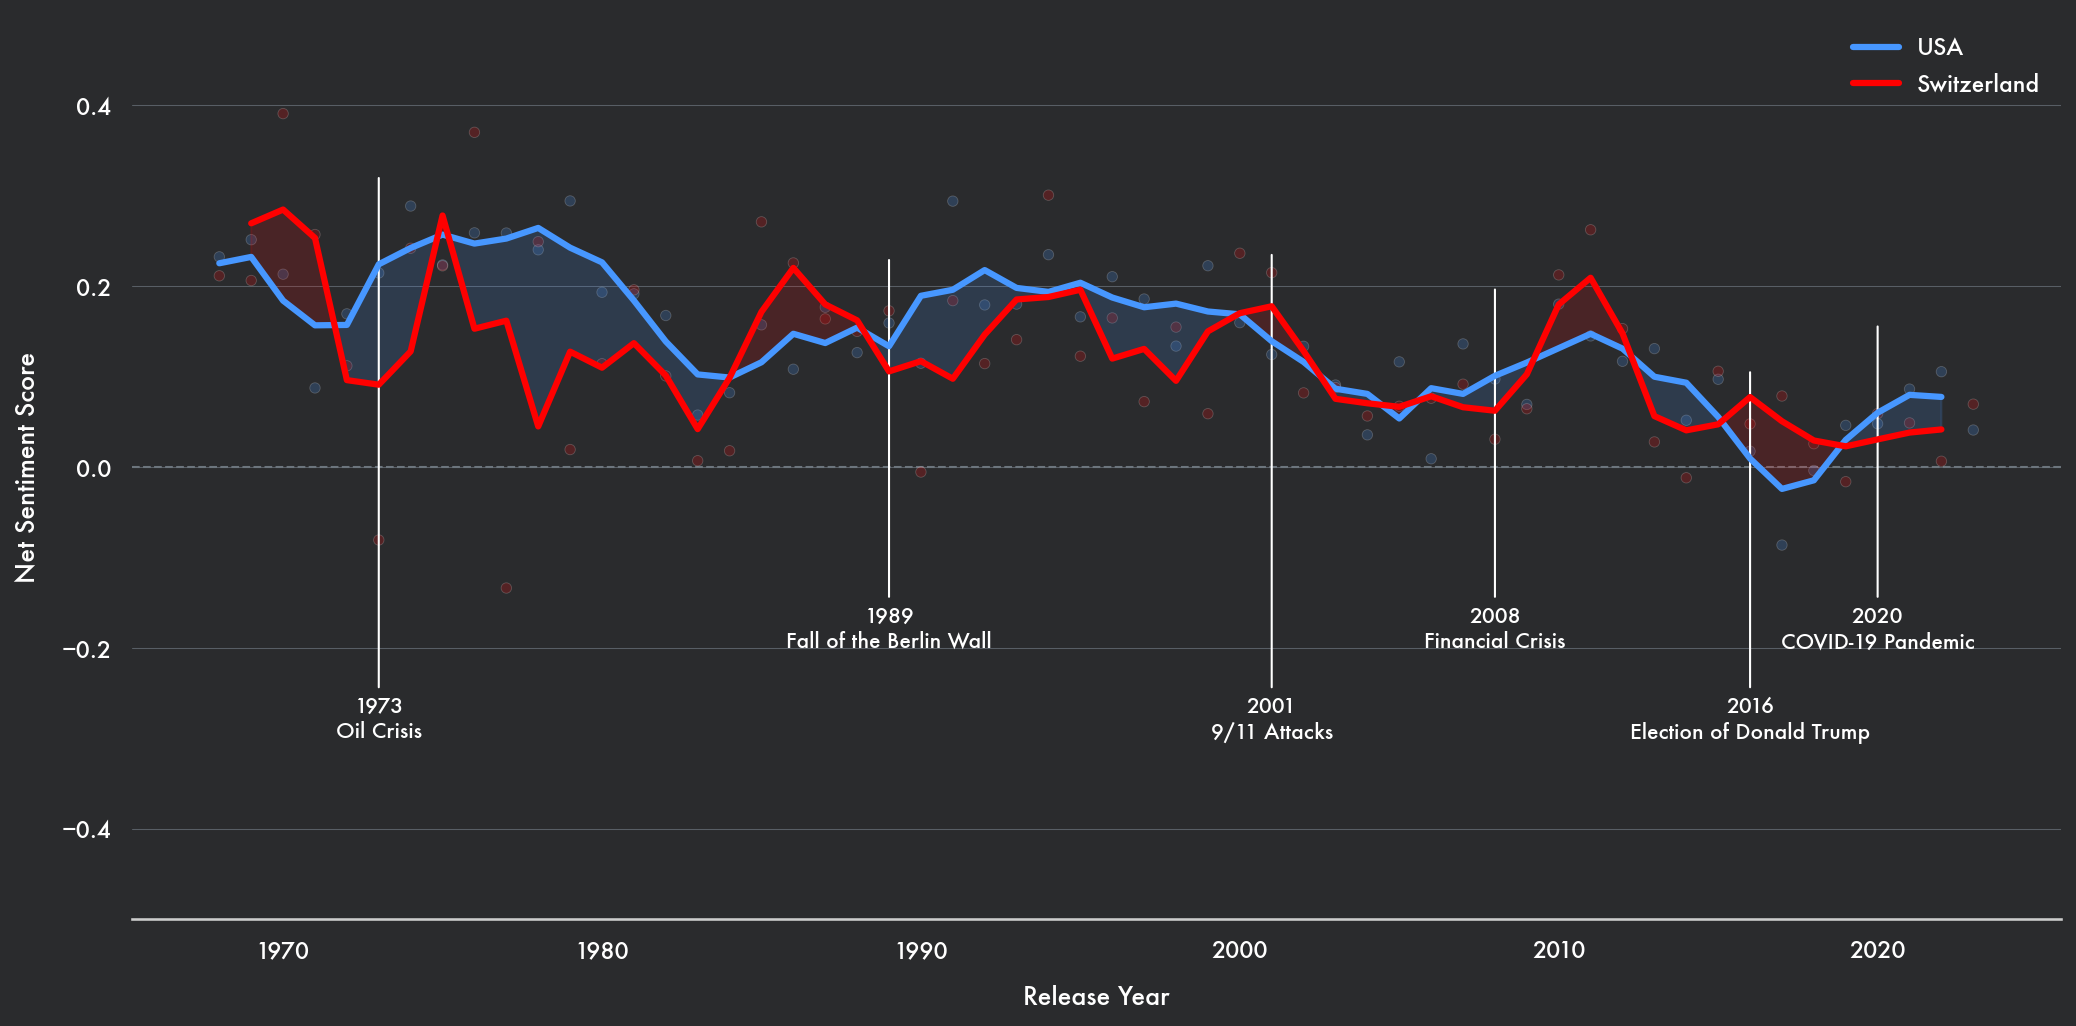

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm
import json

with open('config.json', 'r') as f:
    config = json.load(f)

# Assign colors from config
BG_COLOR = config["colors"]["BG_COLOR"]
TITLE_COLOR = config["colors"]["TITLE_COLOR"]
TEXT_COLOR = config["colors"]["TEXT_COLOR"]
US_COLOR = config["colors"]["US_COLOR"]
CH_COLOR = config["colors"]["CH_COLOR"]
GRID_COLOR = config["colors"]["GRID_COLOR"]
ACCENT_COLOR = config["colors"]["ACCENT_COLOR"]

# Load fonts from config
font_path_title = "style/" + config["fonts"]["title_font_path"]
font_path_main = "style/" + config["fonts"]["main_font_path"]

fm.fontManager.addfont(font_path_title)
fm.fontManager.addfont(font_path_main)

title_font_name = fm.FontProperties(fname=font_path_title).get_name()
main_font_name = fm.FontProperties(fname=font_path_main).get_name()

def process_sentiment_data(df: pd.DataFrame):
    """Convert sentiment scores into yearly net sentiment values."""
    df = df.copy()
    
    # Convert sentiment to signed scores
    conditions = [
        df['Sentiment'] == 'positive',
        df['Sentiment'] == 'negative'
    ]
    choices = [df['Sentiment_Score'], -df['Sentiment_Score']]
    df['Net_Sentiment'] = np.select(conditions, choices, default=0)
            
    # Aggregate by year
    yearly = df.groupby('Year')['Net_Sentiment'].mean().reset_index()
    yearly['smoothed_trend'] = yearly['Net_Sentiment'].rolling(window=3, center=True).mean()
    
    return yearly

def prepare_plot_data(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    """Build merged and reshaped data for the comparison chart."""
    yearly_usa = process_sentiment_data(df_usa)
    yearly_ch = process_sentiment_data(df_ch)
    
    # Merge both countries on year
    merged = pd.merge(yearly_usa, yearly_ch, on='Year', suffixes=('_USA', '_CH'), how='inner')

    # Prep long-format data for seaborn lines
    trend_melted = merged.melt(
        id_vars=['Year'], 
        value_vars=['smoothed_trend_USA', 'smoothed_trend_CH'],
        var_name='Country', 
        value_name='Smoothed_Trend'
    )
    trend_melted['Country'] = trend_melted['Country'].map({'smoothed_trend_USA': 'USA', 'smoothed_trend_CH': 'Switzerland'})

    # Prep long-format data for seaborn scatter
    scatter_melted = merged.melt(
        id_vars=['Year'], 
        value_vars=['Net_Sentiment_USA', 'Net_Sentiment_CH'],
        var_name='Country', 
        value_name='Net_Sentiment'
    )
    scatter_melted['Country'] = scatter_melted['Country'].map({'Net_Sentiment_USA': 'USA', 'Net_Sentiment_CH': 'Switzerland'})
    
    return merged, trend_melted, scatter_melted

def format_plot_aesthetics(ax: plt.Axes, merged_data: pd.DataFrame):
    """Apply the shared styling, labels, and annotations to the plot."""
    sns.despine(left=True, top=True, right=True)
    
    # Add light grid lines
    ax.grid(color=GRID_COLOR, linestyle='-', linewidth=0.5, axis='y', alpha=0.7)
    ax.grid(False, axis='x')
            
    ax.set_xlabel('Release Year', fontsize=12, color=TEXT_COLOR, labelpad=10)
    ax.set_ylabel('Net Sentiment Score', fontsize=12, color=TEXT_COLOR, labelpad=10)
    ax.set_ylim(-0.5, 0.5)

    ax.tick_params(axis='x', colors=TEXT_COLOR)
    ax.tick_params(axis='y', colors=TEXT_COLOR)

    # Define annotations
    timeline_events = {
        1973: "Oil Crisis",
        1989: "Fall of the Berlin Wall",
        2001: "9/11 Attacks",
        2008: "Financial Crisis",
        2016: "Election of Donald Trump",
        2020: "COVID-19 Pandemic"
    }

    toggle = True
    for year, label in timeline_events.items():
        data = merged_data.loc[merged_data['Year'] == year, 'smoothed_trend_USA']
        ax.annotate(f'{year}\n{label}', 
            xy=(year, data.values[0] + 0.1),
            xytext=(year, -0.3 if toggle else -0.2),
            fontsize=10, color=TEXT_COLOR, fontweight='bold', 
            ha='center',
            arrowprops=dict(facecolor=TEXT_COLOR, arrowstyle='-', color=TEXT_COLOR)
        )
        toggle = not toggle

    # Legend cleanup
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='', frameon=False, loc='upper right', fontsize=11, labelcolor=TEXT_COLOR)


def create_comparative_sentiment_chart_sns(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    """Create the sentiment comparison chart for the USA and Switzerland."""
    # Get prepped data
    merged, trend_melted, scatter_melted = prepare_plot_data(df_usa, df_ch)

    # Canvas setup
    sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": BG_COLOR, 
        "figure.facecolor": BG_COLOR,
        "font.family": main_font_name  
    })
    
    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
    palette = {'USA': US_COLOR, 'Switzerland': CH_COLOR}

    # Plot base elements
    ax.axhline(0, color=GRID_COLOR, linestyle='--', linewidth=1, zorder=1)

    sns.scatterplot(data=scatter_melted, x='Year', y='Net_Sentiment', hue='Country', 
                    palette=palette, alpha=0.2, s=25, legend=False, ax=ax, zorder=2)

    sns.lineplot(data=trend_melted, x='Year', y='Smoothed_Trend', hue='Country', 
                 palette=palette, linewidth=3, ax=ax, zorder=4)

    # Shade the gap between lines
    ax.fill_between(merged['Year'], merged['smoothed_trend_USA'], merged['smoothed_trend_CH'],
                    where=(merged['smoothed_trend_USA'] >= merged['smoothed_trend_CH']),
                    color=US_COLOR, alpha=0.15, interpolate=True, zorder=3)

    ax.fill_between(merged['Year'], merged['smoothed_trend_USA'], merged['smoothed_trend_CH'],
                    where=(merged['smoothed_trend_CH'] > merged['smoothed_trend_USA']),
                    color=CH_COLOR, alpha=0.15, interpolate=True, zorder=3)

    # Apply styling and labels
    format_plot_aesthetics(ax, merged)
    
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    # Load datasets
    df_usa = pd.read_csv('data/US/songs_analyzed.csv')
    df_ch = pd.read_csv('data/CH/songs_analyzed.csv') 

    # Generate and show plot
    sentiment_fig = create_comparative_sentiment_chart_sns(df_usa, df_ch)
    plt.show()

    # Save the chart
    sentiment_fig.savefig('chartsPNG/chart1.png', dpi=300, bbox_inches='tight')